In [1]:
from experiments.safety_monitor import *
from utils.signals import low_pass

import numpy as np
import matplotlib.pyplot as plt

In [2]:
npz = np.load('../data/inv_pend/train.npz')
x = npz['states']
f = npz['fail'] > 0

In [3]:
x.shape

(1000, 1000, 4)

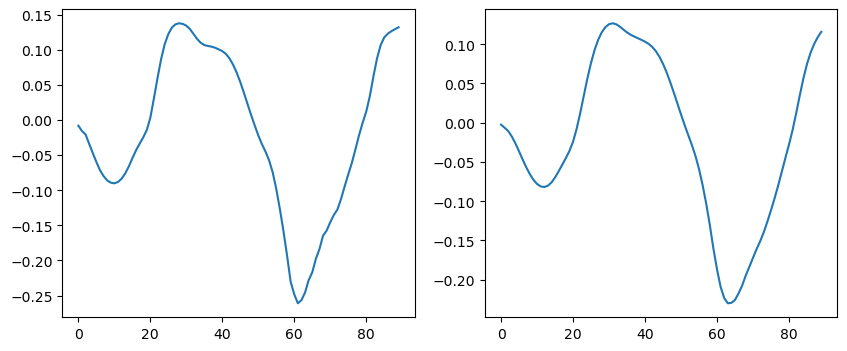

In [5]:
i = np.random.randint(len(x[~f]))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(x[i,:90,1])
ax[1].plot(low_pass(x[i,:90,1], alpha=0.3))

In [6]:
low_pass(x[0], 0.9)

array([[ 4.27614789e-03, -7.03241759e-03, -7.17247777e-05,
         8.56609914e-03],
       [ 1.28658026e-02, -2.35177542e-02,  4.04959733e-01,
        -7.69627763e-01],
       [ 2.60096215e-02, -4.62551209e-02,  2.52117603e-01,
        -3.82211286e-01],
       ...,
       [-1.30667396e-01,  2.80800630e-02,  2.79498618e-01,
        -3.60864038e-01],
       [-1.11598624e-01, -2.47165276e-04,  6.71365377e-01,
        -1.03447732e+00],
       [-9.14134605e-02, -2.53202945e-02,  3.41650758e-01,
        -2.53127519e-01]], shape=(1000, 4))

Text(0.5, 1.0, 'fail')

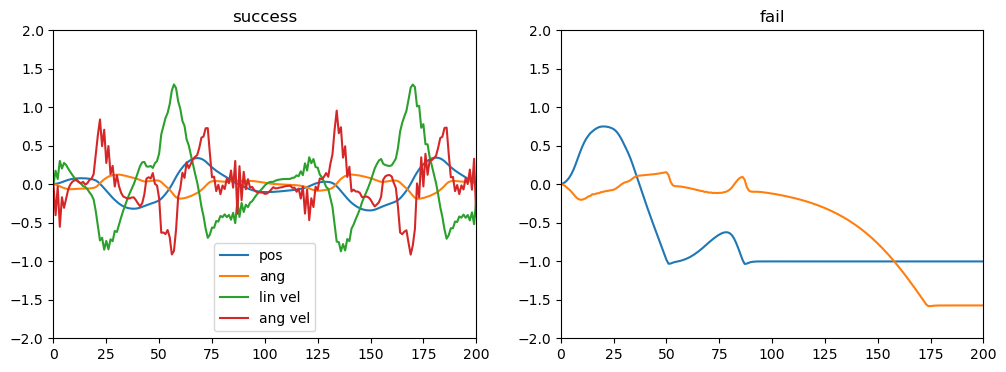

In [17]:
i = np.random.randint(len(x[~f]))
j = np.random.randint(len(x[f]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(x[~f][i,:], label=['pos', 'ang','lin vel','ang vel'])
#ax[0].plot(x[~f][i,:,:2], label=['pos', 'ang'])
ax[0].set_ylim(-2, 2)
ax[0].set_xlim(0, 200)
ax[0].set_title('success')
#ax[0].axhline(0.2, color='C1')
ax[0].legend()
#ax[1].plot(x[f][j,:], label=['pos', 'ang','lin vel','ang vel'])
ax[1].plot(x[f][j,:,:2], label=['pos', 'ang'])
ax[1].set_ylim(-2, 2)
ax[1].set_xlim(0, 200)
ax[1].set_title('fail')
#ax[1].axhline(0.2, color='C1')


In [8]:
SM_CFG

{'inv_pend': SafetyMonitorConfig(win=90, hor=45),
 'hopper': SafetyMonitorConfig(win=70, hor=70),
 'half_cheetah': SafetyMonitorConfig(win=70, hor=10),
 'humanoid': SafetyMonitorConfig(win=22, hor=30)}

In [9]:
task = SafetyMonitor('inv_pend', SM_CFG['inv_pend'])
x_tr, x_te = task.get_train_test()
y = task.y_true

Skipping traj 3 with fail 60: No valid window found.
Skipping traj 5 with fail 51: No valid window found.
Skipping traj 6 with fail 53: No valid window found.
Skipping traj 7 with fail 6: No valid window found.
Skipping traj 8 with fail 54: No valid window found.
Skipping traj 10 with fail 59: No valid window found.
Skipping traj 12 with fail 59: No valid window found.
Skipping traj 14 with fail 6: No valid window found.
Skipping traj 16 with fail 7: No valid window found.
Skipping traj 17 with fail 6: No valid window found.
Skipping traj 21 with fail 62: No valid window found.
Skipping traj 28 with fail 55: No valid window found.
Skipping traj 31 with fail 59: No valid window found.
Skipping traj 32 with fail 59: No valid window found.
Skipping traj 34 with fail 51: No valid window found.
Skipping traj 41 with fail 61: No valid window found.
Skipping traj 43 with fail 57: No valid window found.
Skipping traj 46 with fail 61: No valid window found.
Skipping traj 50 with fail 6: No vali

(-3.0, 3.0)

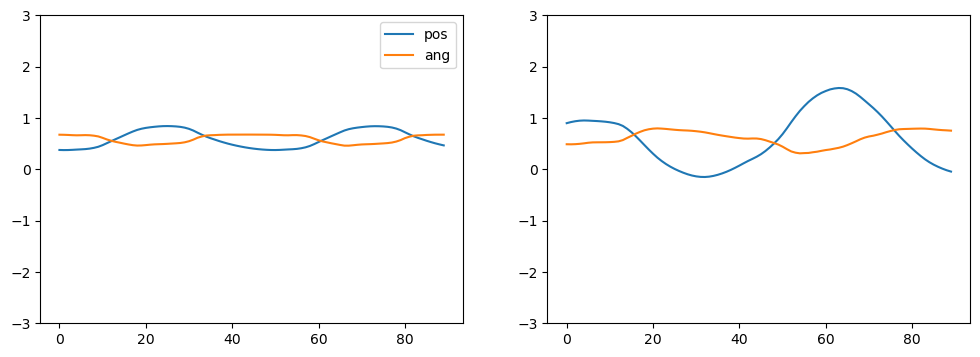

In [10]:
i = np.random.randint(len(x_te[~y]))
j = np.random.randint(len(x_te[y]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

#ax[0].plot(x_te[~y][i,:], label=['pos', 'ang','lin vel','ang vel'])
ax[0].plot(x_te[~y][i,:,:2], label=['pos', 'ang'])
ax[0].set_ylim(-3, 3)
#ax[0].axhline(0.2, color='C1')
ax[0].legend()
#ax[1].plot(x_te[y][j,:], label=['pos', 'ang','lin vel','ang vel'])
ax[1].plot(x_te[y][j,:,:2], label=['pos', 'ang'])
ax[1].set_ylim(-3, 3)
#ax[1].axhline(0.2, color='C1')

